# SuperStore DataAnalysis

## Objective
To analyze the Superstore dataset using data analysis techniques in order to uncover sales trends across categories, sub-categories, regions, customer segments, and time (monthly trends). The objective is to identify key revenue drivers, high-performing products, and customer behavior patterns to support data-driven business decisions.

In [68]:
import pandas as pd

In [69]:
df=pd.read_csv(r'C:\Users\lenovo\Pandas Project 2\train.csv')

In [70]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [72]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [73]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## Data Cleaning

In [74]:
df.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [75]:
df.columns=df.columns.str.strip()
df.columns=df.columns.str.lower().str.replace(' ','_')

In [76]:
df.dropna(subset=['postal_code'],inplace=True)

In [77]:
df['order_date']=pd.to_datetime(df['order_date'],errors='coerce')
df['ship_date']=pd.to_datetime(df['ship_date'],errors='coerce')

In [78]:
df['order_month']=df['order_date'].dt.month
df['order_year']=df['order_date'].dt.year

In [79]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,order_month,order_year
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,8.0,2017.0
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,8.0,2017.0
2,3,CA-2017-138688,2017-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,12.0,2017.0
3,4,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,11.0,2016.0
4,5,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,11.0,2016.0


## Exploratory Data Analysis

In [80]:
#Total sales
df['sales'].sum()

np.float64(2252607.4127)

In [81]:
#Total orders
df['order_id'].nunique() 

4916

In [82]:
#Average order value
df['sales'].sum()/df['order_id'].nunique()

np.float64(458.2195713384866)

In [83]:
#Sales by category
df.groupby('category')['sales'].sum().sort_values(ascending=False)

category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: sales, dtype: float64

In [84]:
#Sales by subcategory
df.groupby('sub-category')['sales'].sum().sort_values(ascending=False).head(10)

sub-category
Phones         326487.6980
Chairs         322107.5310
Storage        217779.1020
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    163881.6900
Copiers        146248.0940
Bookcases      109408.2987
Appliances     104075.4630
Name: sales, dtype: float64

In [85]:
df.groupby('region')['sales'].sum().sort_values(ascending=False)

region
West       710219.6845
East       660589.3560
Central    492646.9132
South      389151.4590
Name: sales, dtype: float64

In [86]:
df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64

In [87]:
df.groupby('order_month')['sales'].sum().sort_values(ascending=False)

order_month
2.0     103951.1600
8.0      96155.4526
1.0      90957.9824
3.0      71788.6906
11.0     68274.3135
9.0      66582.3650
4.0      65094.9490
12.0     64819.3662
5.0      64072.0488
10.0     62563.7830
7.0      61678.7465
6.0      49804.3860
Name: sales, dtype: float64

In [88]:
df.groupby('segment')['sales'].sum().sort_values(ascending=False)

segment
Consumer       1.146708e+06
Corporate      6.822118e+05
Home Office    4.236874e+05
Name: sales, dtype: float64

## Visualizations

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

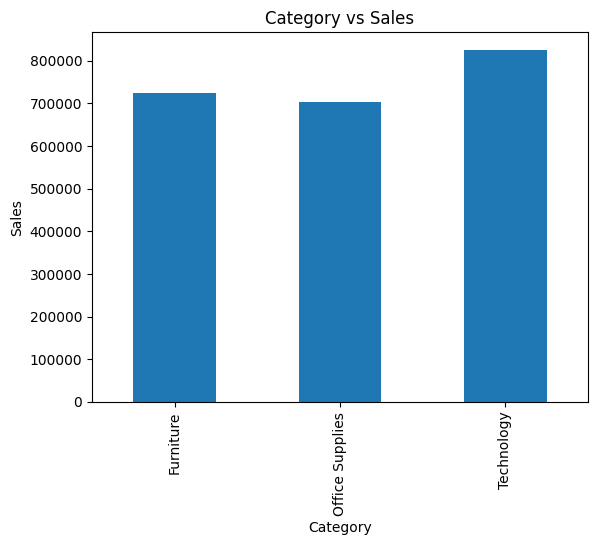

In [90]:
top_categories=df.groupby('category')['sales'].sum().head(10)
top_categories.plot(kind='bar')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.title('Category vs Sales')
plt.show()

In [91]:
import calendar

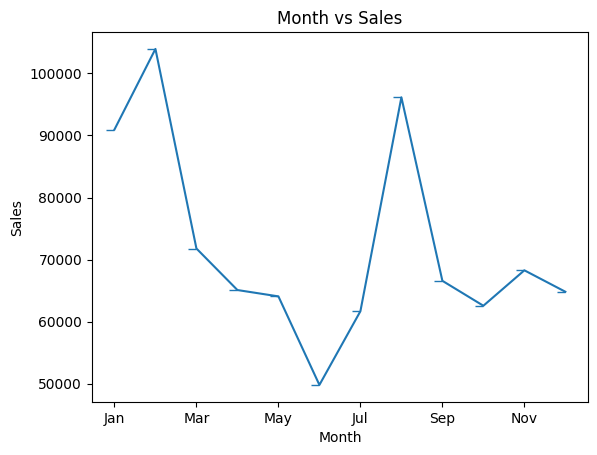

In [92]:
monthly_sales=df.groupby('order_month')['sales'].sum()
monthly_sales.index = monthly_sales.index.map(lambda x: calendar.month_abbr[int(x)])
monthly_sales.plot(kind='line',marker=0)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Month vs Sales')
plt.show()

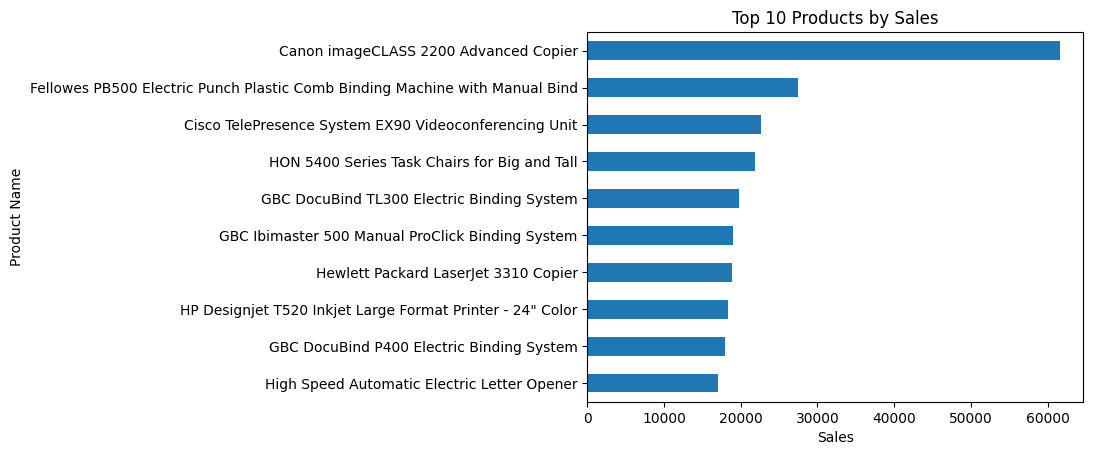

In [93]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

top_products.sort_values().plot(kind='barh')

plt.xlabel('Sales')
plt.ylabel('Product Name')
plt.title('Top 10 Products by Sales')

plt.show()

## Insights

1. Total sales is ₹2252607.4127.

2. The average order value comes out to be ₹458.2195713384866.

3. Technology category generated ₹825856.1130 in sales, which is higher than Furniture and Office Supplies, making it the top-performing category.

4. Phones generate the highest sales among all the sub-categories, indicating high demand for communication devices.

5. The West region leads in sales with ₹710219.6845, significantly outperforming the South region with ₹389151.4590 in sales, thus having the lowest sales. This highlights regional disparities in revenue generation. The higher sales in the West region may be due to higher customer density or stronger market presence, suggesting potential areas for expansion in underperforming regions.

6. Canon imageCLASS 2200 Advanced Copier generated ₹61599.824 in sales, the highest among all products, outperforming the next best product by a significant margin, making it a major revenue driver.This indicates that high-value office equipment contributes significantly to revenue, suggesting a focus on premium products can boost overall sales performance.

7. February recorded sales of ₹103,951, outperforming August (₹96,155), suggesting stronger demand in the early part of the year and possible seasonal variations in sales performance. 

8. The Consumer segment generates the highest sales among all segments, indicating that individual customers are the primary contributors to overall revenue. This suggests that the business is heavily reliant on individual consumers, and targeting this segment with marketing strategies could further enhance sales growth

## Conclusion

The analysis of the Superstore dataset reveals that the Technology category is the primary driver of revenue, with sub-categories like Phones contributing significantly to overall sales. Region-wise analysis shows that the West region outperforms others, indicating stronger market presence and demand in that area.

At the product level, high-value items such as the Canon imageCLASS 2200 Advanced Copier generate substantial revenue, highlighting the importance of premium products. Additionally, the Consumer segment dominates sales, suggesting that individual customers are the key contributors to business growth.

Monthly trend analysis indicates variations in sales across the year, with certain months like February showing higher performance, suggesting possible seasonal demand patterns.

Overall, the business relies heavily on specific categories, regions, and customer segments. Focusing on high-performing areas and improving strategies in underperforming segments can help drive future growth.